## IEOR4004: A Day in Manhattan

Your family is visiting New York City for the first time and have just one day to explore. Starting from their hotel in Midtown, they want to experience key aspects of the city: culture, green space, iconic landmarks, and food. 

You must visit all required locations:
- Times Square 
- Columbia University Campus
- Jacqueline Kennedy Onassis Reservoir at the Central Park and the MET
- Restaurants: Where you'll grab food. (there are 2 options, just visit one!)

The map is given here:
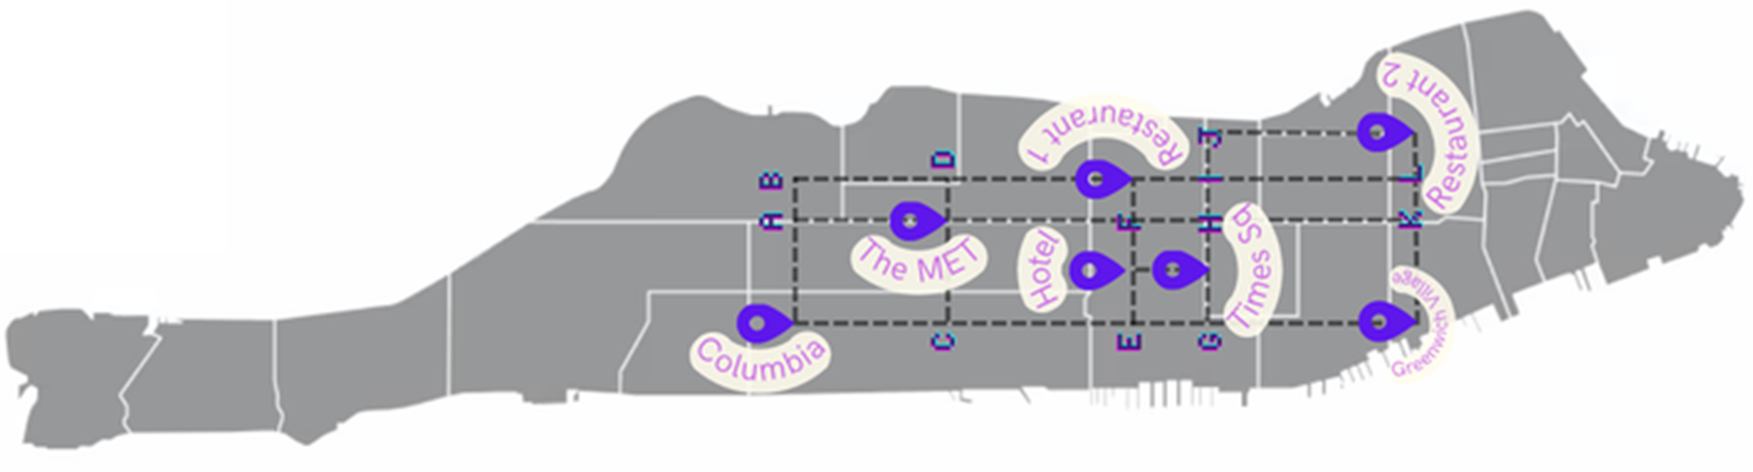

<br> Your task is to plan the most efficient route from their hotel, hitting these key points while avoiding unnecessary detours through tourist-infested areas. Your map is given below. 



In [73]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import gurobipy as gp
from gurobipy import *

In [49]:
locations = {
    # Key locations
    "Columbia": (0,15000),
    "MetMuseum": (1200,9000), 
    "Hotel": (600, 4800),
    "TimesSquare": (600, 3000),
    "GreenwichVillage" : (0,0),

    "Restaurant1": (1700, 4800),
    "Restaurant2": (2000, 0),

    # Grid nodes (aligned with your dashed grid)
    "A": (1200,15000),
    "B": (1700,15000),

    "C": (0, 9000),
    "D": (1700, 9000),

    "E": (0, 4800),
    "F": (1200, 4800),

    "G": (0, 3000),
    "H": (1200, 3000),
    "I": (1700, 3000),
    "J": (2000, 3000),

    "K": (1200, 0),
    "L": (1700, 0)
}

edges = [ ("GreenwichVillage","K" ),("K", "L"), ( "L","Restaurant2"), 
          ( "J","Restaurant2"),("L", "I"), ("K", "H"),("GreenwichVillage","G" ), 
          ("TimesSquare", "G"),("TimesSquare", "H"), ("I", "H"), ("I", "J"),
          ("E", "Hotel"), ("F", "Hotel"), ("F", "Restaurant1"), 
          ("I", "Restaurant1"),("H", "F"), ("TimesSquare", "Hotel"), ("G", "E"),
          ("E", "C"),("F", "MetMuseum"),("Restaurant1", "D"),
          ("D", "MetMuseum"),("MetMuseum", "C"),
          ("C", "Columbia"),("MetMuseum", "A"),("D", "B"),
          ("A", "B"), ("A", "Columbia")]

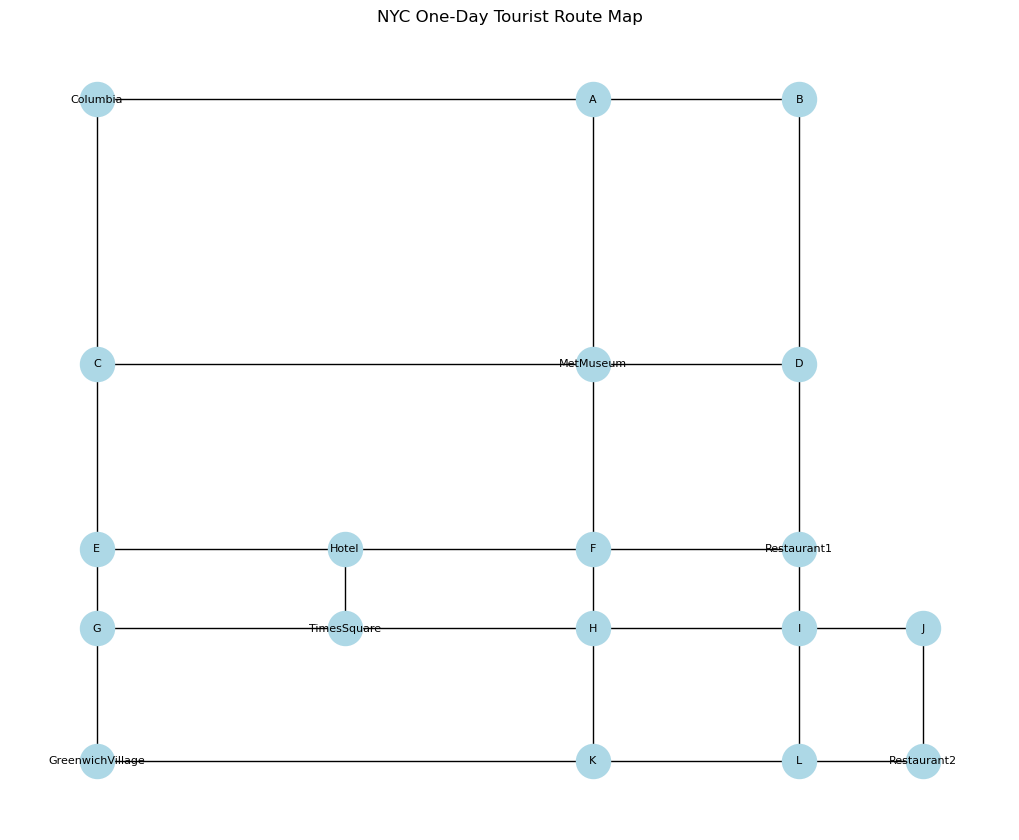

In [50]:
# Create graph
G = nx.Graph()

# Add nodes
for node, pos in locations.items():
    G.add_node(node, pos=pos)

# Add edges
G.add_edges_from(edges)

# Extract positions
pos = nx.get_node_attributes(G, 'pos')

# Draw
plt.figure(figsize=(10, 8))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=600,
    node_color='lightblue',
    font_size=8,
    font_color='black'
)

plt.title("NYC One-Day Tourist Route Map")
plt.show()

In [51]:
#List of nodes
nodes = list(locations.keys())

#Number of nodes
num_nodes = len(locations)

# Set of required nodes
required_nodes = {"Columbia", "MetMuseum", "Hotel", "TimesSquare"}
non_required_nodes = set(nodes) - set(required_nodes)

#All edges
all_edges = edges + [(b, a) for a, b in edges]

# Filter edges to include only those with at least one node in required_nodes
required_edges = [edge for edge in all_edges if edge[0] in required_nodes or edge[1] in required_nodes]
all_required_edges = required_edges + [(b, a) for a, b in required_edges]

# Filter edges to include only those where neither endpoint is in required_nodes
non_required_edges = [edge for edge in all_edges if edge[0] not in required_nodes and edge[1] not in required_nodes]
all_non_required_edges = non_required_edges + [(b, a) for a, b in non_required_edges]

# Display the filtered edges
# print( f"These are the required edges: {all_required_edges}")
# print( f"These are the non-required edges: {all_non_required_edges}")

#Distance between nodes
dist = {(i, j): abs(pos[i][0] - pos[j][0]) + abs(pos[i][1] - pos[j][1]) for i, j in all_edges}
# print(dist)

In [60]:
# Add weights to a new weighted graph
G_weighted = nx.Graph()
for node, p in locations.items():
    G_weighted.add_node(node, pos=p)

for (u, v), d in dist.items():
    G_weighted.add_edge(u, v, weight=d)

# Key stops we care about
key_stops = ["Hotel", "Columbia", "MetMuseum", "TimesSquare", "Restaurant1", "Restaurant2"]

# Compute weighted shortest path distance and actual path between every pair
dist = {}
path = {}
for s in key_stops:
    for t in key_stops:
        if s != t:
            dist[(s, t)] = nx.shortest_path_length(G_weighted, s, t, weight='weight')
            path[(s, t)] = nx.shortest_path(G_weighted, s, t, weight='weight')


for (s, t), d in dist.items():
    print(f"  {s:20s} → {t:20s} : {int(d):>6} units")

  Hotel                → Columbia             :  10800 units
  Hotel                → MetMuseum            :   4800 units
  Hotel                → TimesSquare          :   1800 units
  Hotel                → Restaurant1          :   1100 units
  Hotel                → Restaurant2          :   6200 units
  Columbia             → Hotel                :  10800 units
  Columbia             → MetMuseum            :   7200 units
  Columbia             → TimesSquare          :  12600 units
  Columbia             → Restaurant1          :  11900 units
  Columbia             → Restaurant2          :  17000 units
  MetMuseum            → Hotel                :   4800 units
  MetMuseum            → Columbia             :   7200 units
  MetMuseum            → TimesSquare          :   6600 units
  MetMuseum            → Restaurant1          :   4700 units
  MetMuseum            → Restaurant2          :   9800 units
  TimesSquare          → Hotel                :   1800 units
  TimesSquare          →

In [58]:
def solve_tsp(stops, start="Hotel", verbose=True):
    n   = len(stops)
    idx = {s: i for i, s in enumerate(stops)}
    c   = {(i, j): sp_len[stops[i]][stops[j]]
           for i in range(n) for j in range(n) if i != j}

    m = gp.Model("TSP")
    m.Params.OutputFlag = 0         

    # --- Variables ---
    x = m.addVars(n, n, vtype=GRB.BINARY, name="x")
    u = m.addVars(n, lb=0, ub=n - 1,    name="u") 

    # Fix start node position to 0
    s0 = idx[start]
    u[s0].lb = 0
    u[s0].ub = 0

    # --- Objective ---
    m.setObjective(
        gp.quicksum(c[i, j] * x[i, j] for i in range(n) for j in range(n) if i != j),
        GRB.MINIMIZE
    )

    # --- Degree constraints ---
    for i in range(n):
        m.addConstr(gp.quicksum(x[i, j] for j in range(n) if j != i) == 1, name=f"out_{i}")
        m.addConstr(gp.quicksum(x[j, i] for j in range(n) if j != i) == 1, name=f"in_{i}")

    # --- MTZ subtour-elimination constraints ---
    for i in range(n):
        for j in range(n):
            if i != j and i != s0 and j != s0:
                m.addConstr(u[i] - u[j] + n * x[i, j] <= n - 1, name=f"mtz_{i}_{j}")

    m.optimize()

    if m.status != GRB.OPTIMAL:
        print("  No optimal solution found — status:", m.status)
        return None, None

    # Recover ordered route
    route   = [start]
    cur     = idx[start]
    visited = {cur}
    for _ in range(n - 1):
        nxt = next(j for j in range(n)
                   if j not in visited and x[cur, j].X > 0.5)
        route.append(stops[nxt])
        visited.add(nxt)
        cur = nxt
    route.append(start)             

    return m.ObjVal, route



required = ["Hotel", "Columbia", "MetMuseum", "TimesSquare"]

best_obj, best_route, best_rest = float("inf"), None, None


for rest in ["Restaurant1", "Restaurant2"]:
    stops = required + [rest]
    obj, route = solve_tsp(stops)
    print(f"\nRestaurant option : {rest}")
    print(f"  TSP distance    : {obj:.0f}")
    print(f"  Key-stop route  : {' -> '.join(route)}")
    if obj < best_obj:
        best_obj, best_route, best_rest = obj, route, rest

print()

print(f"OPTIMAL RESTAURANT : {best_rest}")
print(f"TOTAL DISTANCE     : {best_obj:.0f}")
print(f"KEY-STOP ROUTE     : {' -> '.join(best_route)}")


Restaurant option : Restaurant1
  TSP distance    : 27400
  Key-stop route  : Hotel -> TimesSquare -> Columbia -> MetMuseum -> Restaurant1 -> Hotel

Restaurant option : Restaurant2
  TSP distance    : 34000
  Key-stop route  : Hotel -> Columbia -> MetMuseum -> Restaurant2 -> TimesSquare -> Hotel

OPTIMAL RESTAURANT : Restaurant1
TOTAL DISTANCE     : 27400
KEY-STOP ROUTE     : Hotel -> TimesSquare -> Columbia -> MetMuseum -> Restaurant1 -> Hotel


In [68]:
full_path = []

for i in range(len(best_route) - 1):
    seg = path[(best_route[i], best_route[i + 1])] 
    
    if full_path:
        seg = seg[1:]  # avoid duplicate node
    
    full_path.extend(seg)

print("Full path (every node traversed):")
print(" -> ".join(full_path))

print(f"\nTotal nodes visited (incl. intermediates): {len(full_path)}")
print(f"Total distance: {best_obj:.0f}")

Full path (every node traversed):
Hotel -> TimesSquare -> G -> E -> C -> Columbia -> C -> MetMuseum -> F -> Restaurant1 -> F -> Hotel

Total nodes visited (incl. intermediates): 12
Total distance: 27400


/var/folders/lw/rn207wnn7w91lfwdwgl46yp00000gn/T/ipykernel_60341/1273992917.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


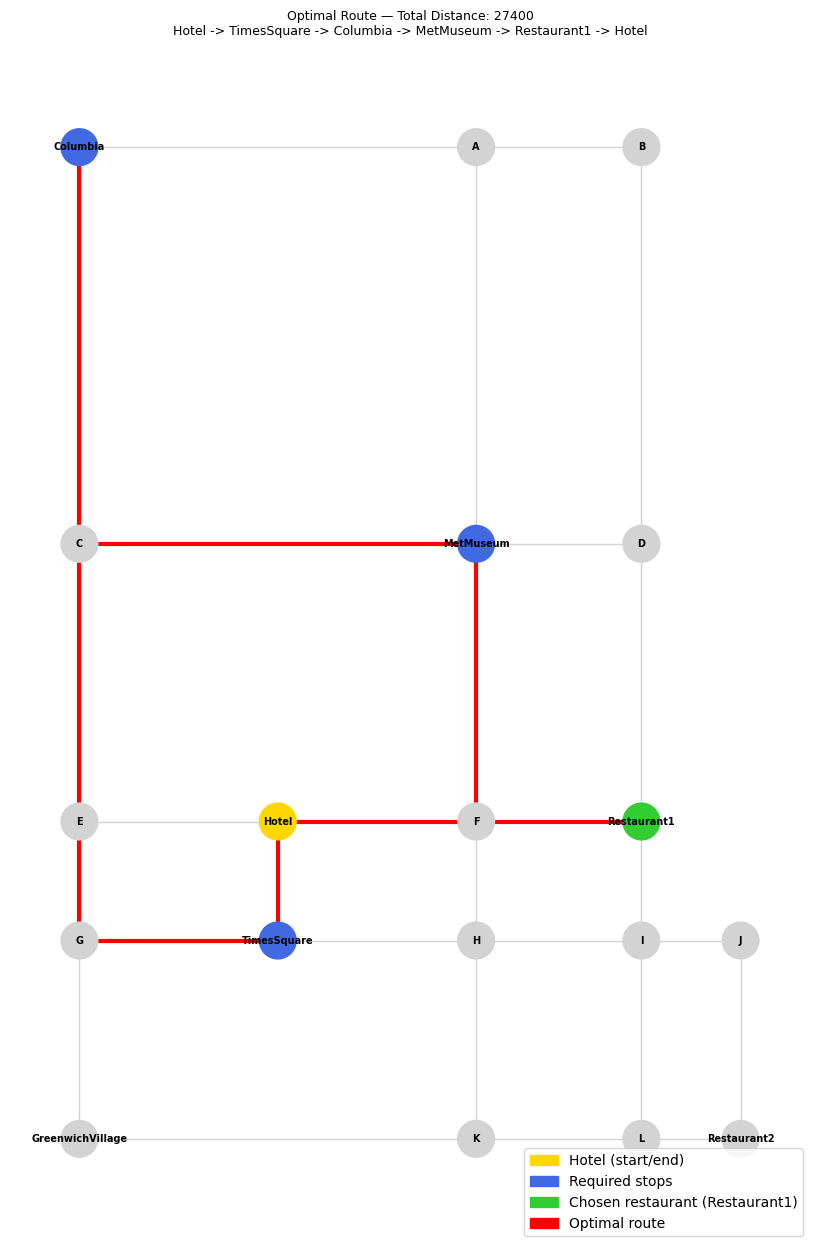

In [69]:
route_edges = [(full_path[i], full_path[i + 1]) for i in range(len(full_path) - 1)]


highlight = {"Hotel": "gold", "Columbia": "royalblue", "MetMuseum": "royalblue",
             "TimesSquare": "royalblue", best_rest: "limegreen"}
node_colors = [highlight.get(n, "lightgrey") for n in G_nx.nodes()]


edge_colors = []
for u, v in G_nx.edges():
    if (u, v) in route_edges or (v, u) in route_edges:
        edge_colors.append("red")
    else:
        edge_colors.append("lightgrey")

plt.figure(figsize=(8, 12))
nx.draw(
    G_nx, pos,
    with_labels=True,
    node_color=node_colors,
    edge_color=edge_colors,
    width=[3 if c == "red" else 1 for c in edge_colors],
    node_size=700,
    font_size=7,
    font_weight="bold"
)
patches = [
    mpatches.Patch(color="gold",      label="Hotel (start/end)"),
    mpatches.Patch(color="royalblue", label="Required stops"),
    mpatches.Patch(color="limegreen", label=f"Chosen restaurant ({best_rest})"),
    mpatches.Patch(color="red",       label="Optimal route"),
]
plt.legend(handles=patches, loc="lower right")
plt.title(f"Optimal Route — Total Distance: {best_obj:.0f}\n"
          f"{' -> '.join(best_route)}", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
#### Approximation

In [70]:
from networkx.algorithms import approximation as approx

def run_greedy_tsp(stop_list, dist, pos, title_suffix=""):

    n = len(stop_list)
    idx  = {s: i for i, s in enumerate(stop_list)}   # name -> int
    ridx = {i: s for s, i in idx.items()}             # int -> name

    # Build complete directed graph on just these stops
    G_tsp = nx.DiGraph()
    G_tsp.add_nodes_from(range(n))
    for i in range(n):
        for j in range(n):
            if i != j:
                s, t = stop_list[i], stop_list[j]
                G_tsp.add_edge(i, j, weight=dist[(s, t)])

    # Run greedy nearest-neighbor TSP
    tour_int = approx.traveling_salesman_problem(
        G_tsp,
        weight="weight",
        cycle=True,
        method=approx.traveling_salesman.greedy_tsp
    )

    # Convert integer tour back to named stops
    tour_named = [ridx[i] for i in tour_int]


    tour_len = sum(
        dist[(tour_named[i], tour_named[i + 1])]
        for i in range(len(tour_named) - 1)
    )

    # --- Coordinates for plotting (from global pos dict) ---
    x_coords = [pos[stop][0] for stop in stop_list]
    y_coords = [pos[stop][1] for stop in stop_list]

    # --- Plot ---
    plt.figure(figsize=(7, 10))

    # Draw all non-tour edges faintly
    for i in range(n):
        for j in range(i + 1, n):
            s, t = stop_list[i], stop_list[j]
            x0, y0 = pos[s]
            x1, y1 = pos[t]
            plt.plot([x0, x1], [y0, y1], color='#e0e0e0', linewidth=1, zorder=1)

    # Draw tour edges
    for i in range(len(tour_named) - 1):
        s, t = tour_named[i], tour_named[i + 1]
        x0, y0 = pos[s]
        x1, y1 = pos[t]
        plt.annotate(
            "",
            xy=(x1, y1), xytext=(x0, y0),
            arrowprops=dict(arrowstyle="->", color="royalblue", lw=2.5),
            zorder=2
        )

    # Draw nodes
    colors = []
    for stop in stop_list:
        if stop == "Hotel":
            colors.append("gold")
        elif "Restaurant" in stop:
            colors.append("limegreen")
        else:
            colors.append("royalblue")

    plt.scatter(x_coords, y_coords, c=colors, s=200, zorder=3, edgecolors='black', linewidths=0.8)

    # Labels with step numbers from tour
    tour_order = {stop: tour_named.index(stop) for stop in stop_list}
    for stop in stop_list:
        x, y = pos[stop]
        step = tour_order[stop]
        plt.text(x + 60, y + 60, f"{step}. {stop}", fontsize=8, fontweight='bold', zorder=4)

    plt.title(
        f"Nearest-Neighbor (Greedy) TSP — {title_suffix}\n"
        f"Tour: {' -> '.join(tour_named)}\n"
        f"Total Distance: {int(tour_len)} units",
        fontsize=9
    )
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.tight_layout()
    plt.show()

    return tour_named, tour_len





Greedy NN TSP — Restaurant 1


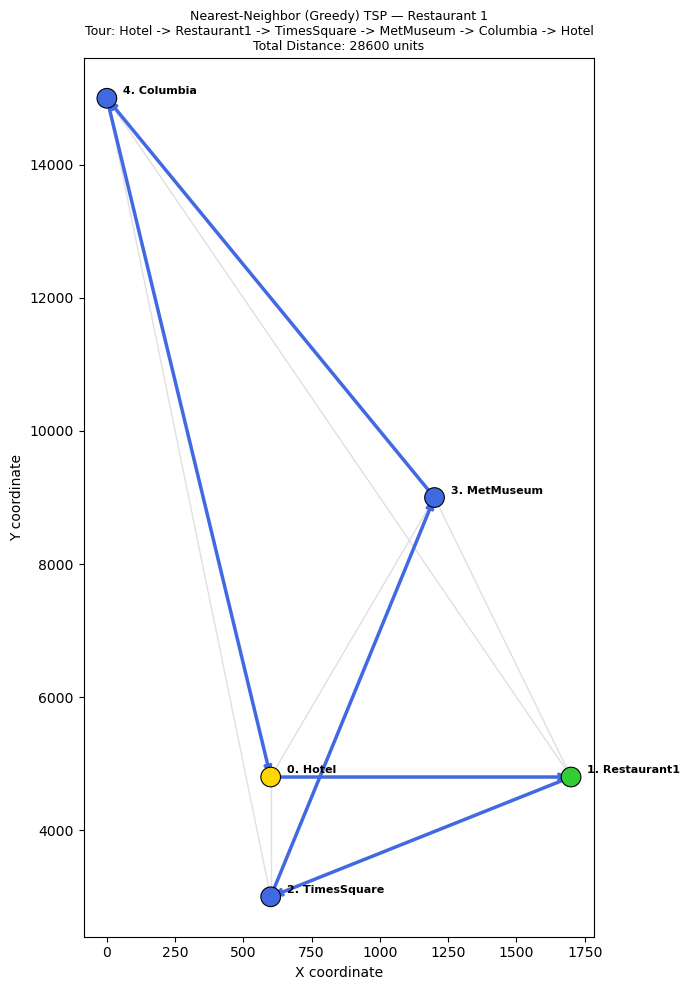

  Tour:           Hotel -> Restaurant1 -> TimesSquare -> MetMuseum -> Columbia -> Hotel
  Total distance: 28600 units


In [71]:
# --- Run greedy TSP for both restaurant options ---
required = ["Hotel", "Columbia", "MetMuseum", "TimesSquare"]


print("Greedy NN TSP — Restaurant 1")

greedy_tour_r1, greedy_len_r1 = run_greedy_tsp(
    required + ["Restaurant1"], dist, pos, title_suffix="Restaurant 1"
)
print(f"  Tour:           {' -> '.join(greedy_tour_r1)}")
print(f"  Total distance: {int(greedy_len_r1)} units")



Greedy NN TSP — Restaurant 2


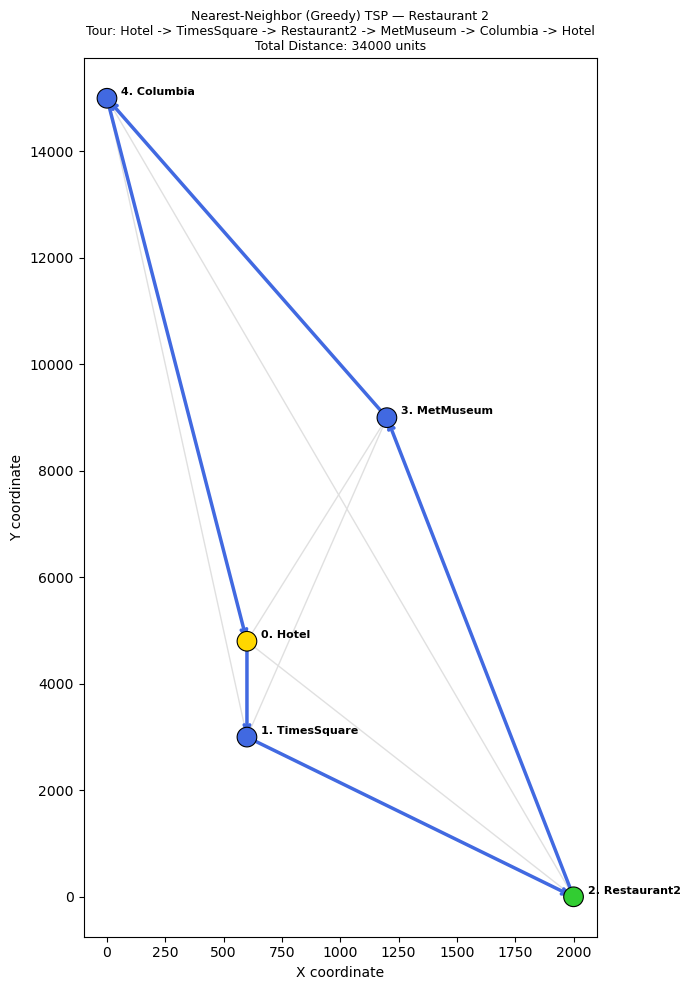

  Tour:           Hotel -> TimesSquare -> Restaurant2 -> MetMuseum -> Columbia -> Hotel
  Total distance: 34000 units


In [72]:
print("Greedy NN TSP — Restaurant 2")

greedy_tour_r2, greedy_len_r2 = run_greedy_tsp(
    required + ["Restaurant2"], dist, pos, title_suffix="Restaurant 2"
)
print(f"  Tour:           {' -> '.join(greedy_tour_r2)}")
print(f"  Total distance: {int(greedy_len_r2)} units")

# --- Greedy best ---
if greedy_len_r1 <= greedy_len_r2:
    greedy_best_len, greedy_best_tour, greedy_best_rest = greedy_len_r1, greedy_tour_r1, "Restaurant1"
else:
    greedy_best_len, greedy_best_tour, greedy_best_rest = greedy_len_r2, greedy_tour_r2, "Restaurant2"

